In [35]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [36]:
adata_cd14mono = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop5/adata_500k_residual.h5ad")

In [37]:
adata_cd14mono = adata_cd14mono[adata_cd14mono.obs.experiment_number.isin(["270", "271"])]

In [38]:
adata_cd14mono.obs.experiment_number

200996-32    270
302316-32    270
250147-33    270
8094-33      270
9063-30      270
            ... 
276201-39    271
155442-38    271
99475-36     271
271277-39    271
88876-39     271
Name: experiment_number, Length: 50000, dtype: category
Categories (2, object): ['270', '271']

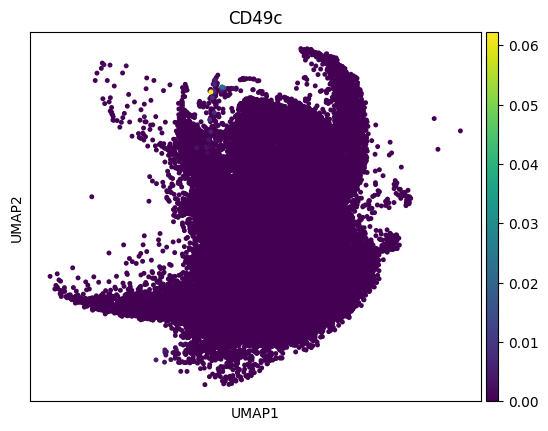

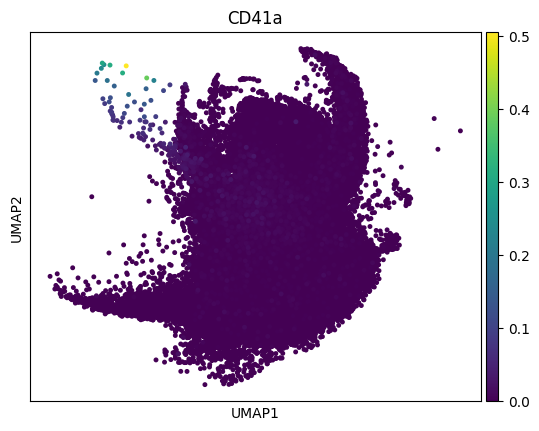

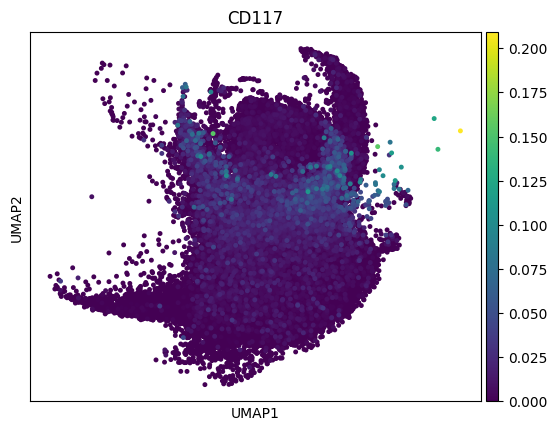

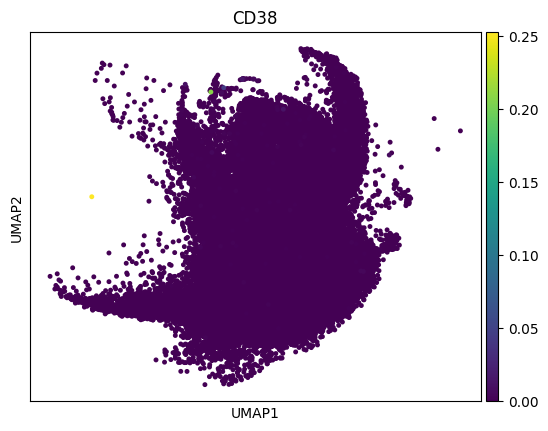

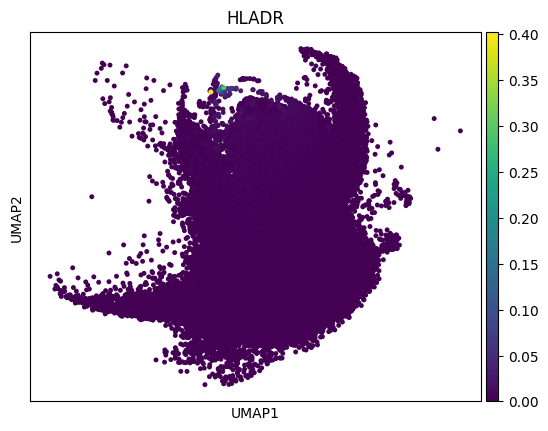

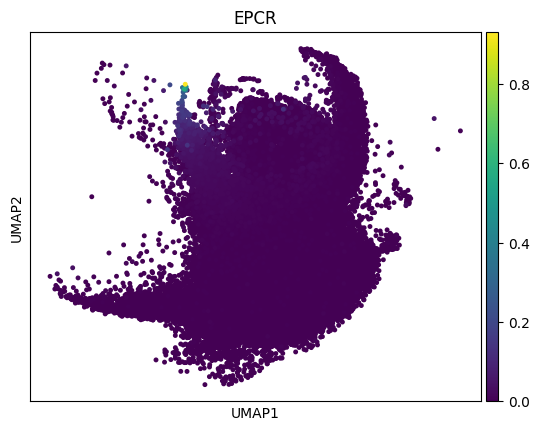

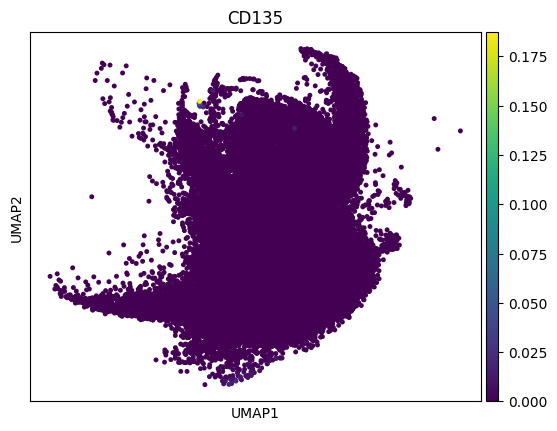

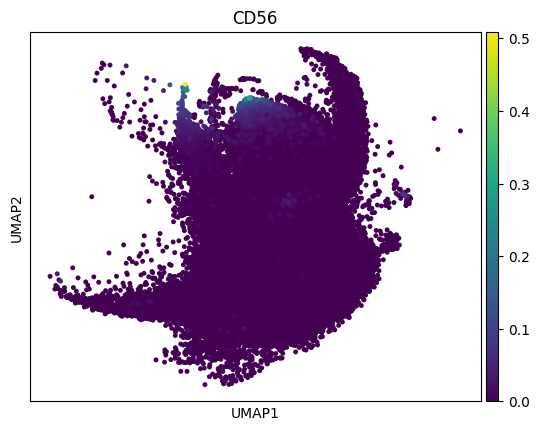

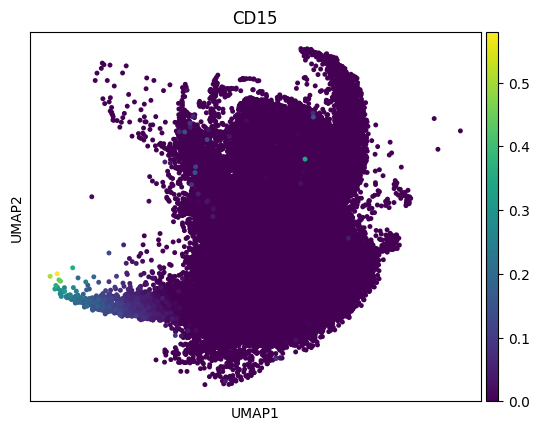

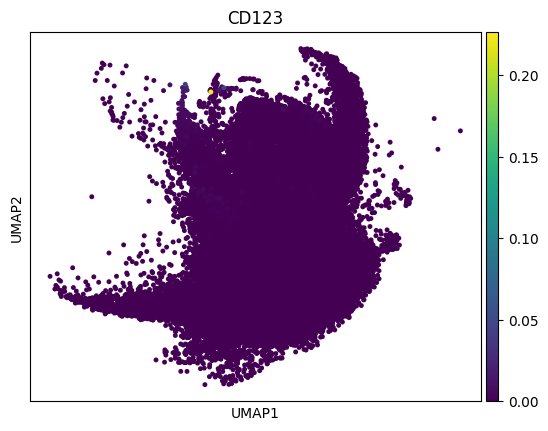

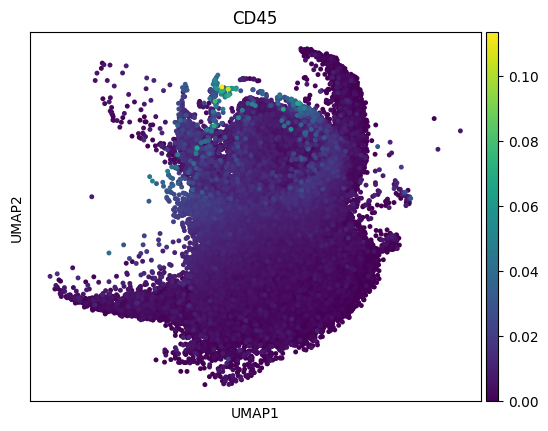

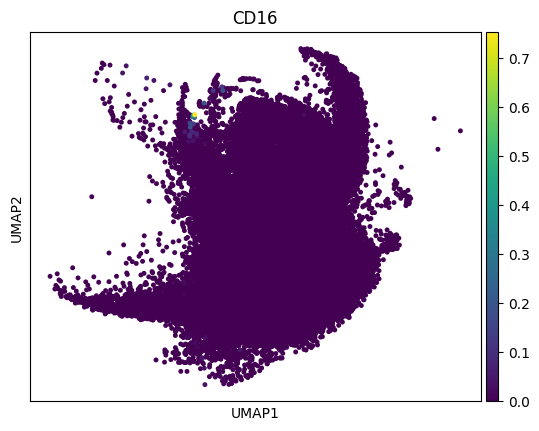

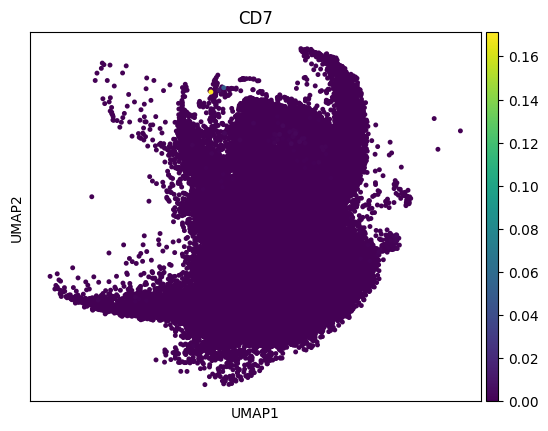

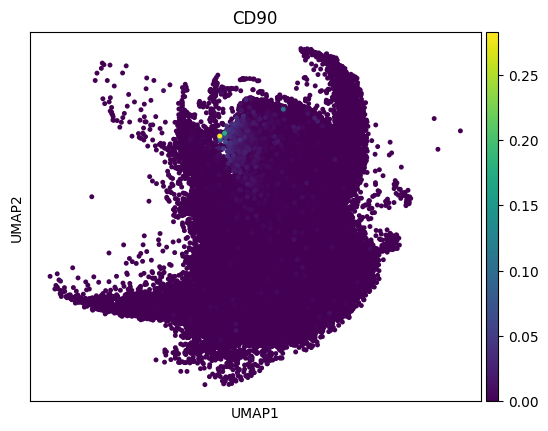

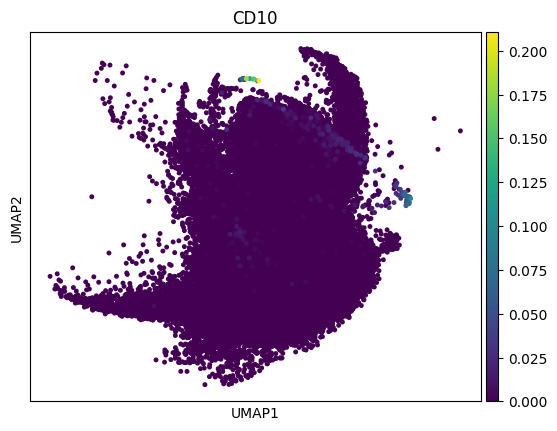

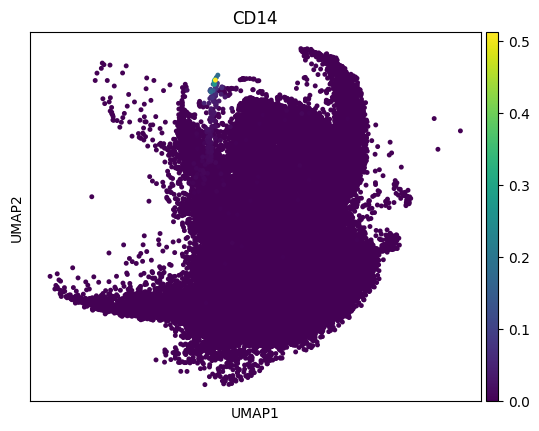

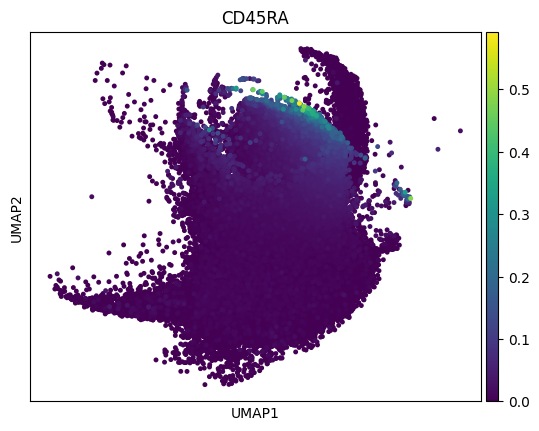

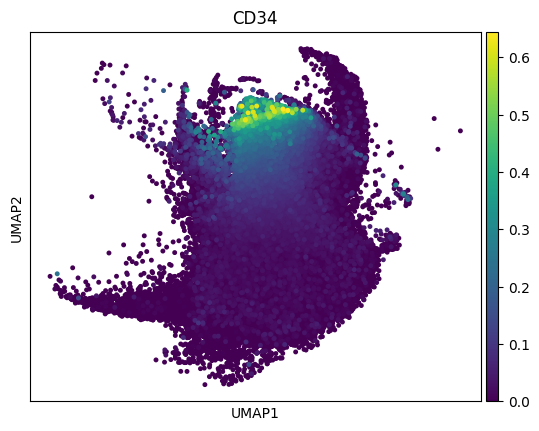

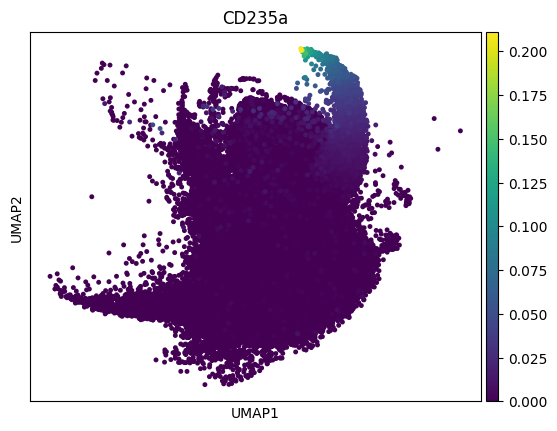

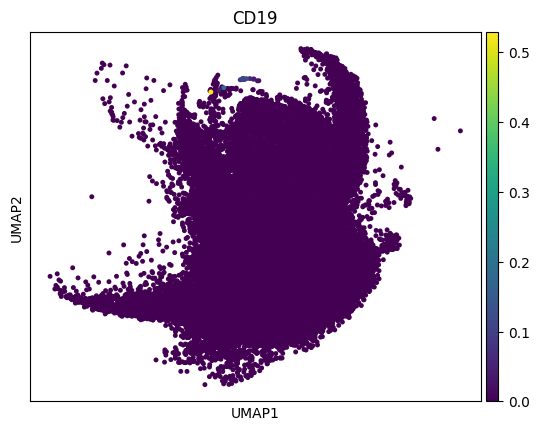

In [39]:
for marker in adata_cd14mono.var.index:
    sc.pl.umap(adata_cd14mono, color=marker, s=50)

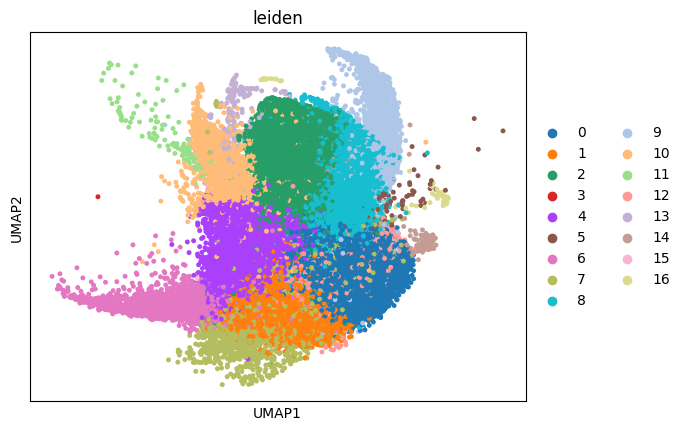

In [40]:
sc.pl.umap(adata_cd14mono, color="leiden", s=50)

## Check comparison CD41a 

In [20]:
cd14_df = {"CD14": adata_cd14mono[:,"CD14"].X.toarray().ravel(), 
           "experiment_number": adata_cd14mono.obs["experiment_number"].values}

In [21]:
cd14_df = pd.DataFrame(cd14_df)

<Axes: xlabel='experiment_number', ylabel='CD14'>

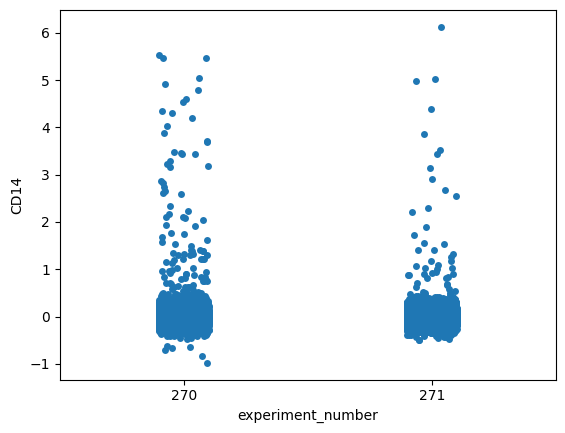

In [22]:
sns.stripplot(cd14_df, x="experiment_number", y="CD14")

# Classification 

In [23]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [24]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_cd14mono.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_cd14mono.obs.columns
]

In [25]:
X_channel = adata_cd14mono.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_cd14mono.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(50000, 20) X_scatter.shape=(50000, 6)


In [26]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 13/13 [00:05<00:00,  2.59it/s]


In [27]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [28]:
ct_predictions_str = classes[ct_predictions]
adata_cd14mono.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_2293908/760667350.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cd14mono.obs["cell_type"] = ct_predictions_str


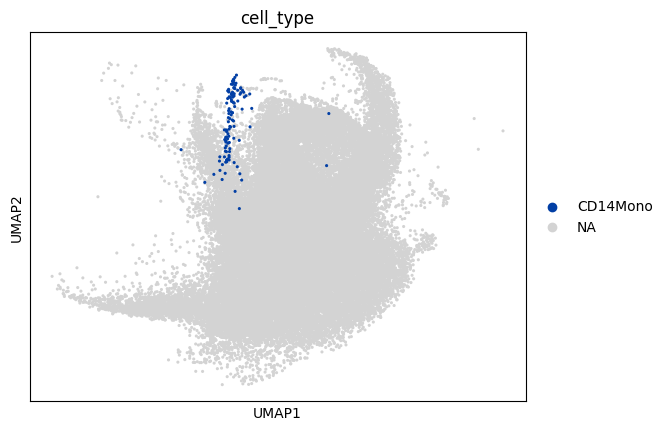

In [29]:
sc.pl.umap(adata_cd14mono, color="cell_type", s=20, groups="CD14Mono")

## Plot cell type props

In [30]:
unique_ct = np.unique(adata_cd14mono.obs["cell_type"])

In [31]:
props_per_exp = {"Exp": [], 
                "mean_cd14": [],
                "prop_cd14mono": [],
                "prop_cd14mono_lin": [],}
for exp in ["270", "271"]:
    adata_cd14mono_exp = adata_cd14mono[adata_cd14mono.obs["experiment_number"]==exp]
    props = adata_cd14mono_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_cd14mono"].append(props["CD14Mono"])
    for ct in unique_ct: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["prop_cd14mono_lin"].append(props["CD14Mono"]+props["CD16Mono"])

    cd14_vals = adata_cd14mono_exp[:, "CD14"].X.toarray().ravel()
    top25_thresh = np.quantile(cd14_vals, 0.75)
    props_per_exp["mean_cd14"].append(cd14_vals[cd14_vals >= top25_thresh].mean())

In [32]:
props_per_exp_df = pd.DataFrame(props_per_exp)

<Axes: xlabel='Exp', ylabel='prop_cd14mono_lin'>

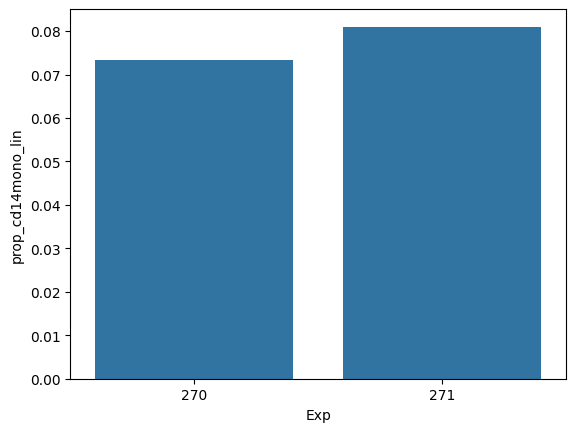

In [33]:
sns.barplot(props_per_exp_df, x="Exp", y="prop_cd14mono_lin")

<Axes: xlabel='Exp', ylabel='prop_cd14mono'>

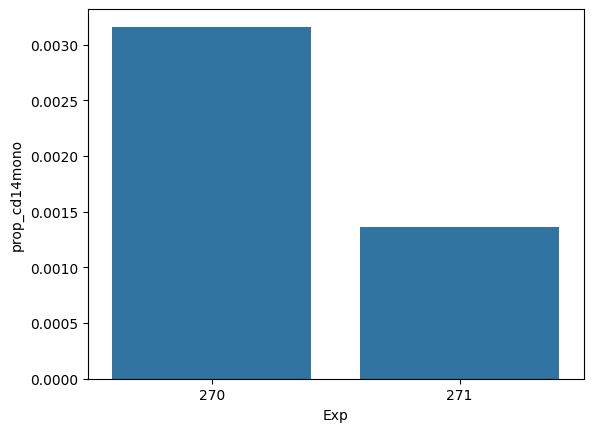

In [34]:
sns.barplot(props_per_exp_df, x="Exp", y="prop_cd14mono")

## Compare to existing protocols

In [41]:
adata_l1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_l2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_l2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_l3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

In [42]:
adata_concat = sc.concat([adata_l1, adata_l2, adata_l2p5, adata_l3])                       

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [43]:
adata_concat.obs["experiment_number"] = adata_concat.obs["experiment_number"].astype(str)

In [44]:
for exp in np.unique(adata_concat.obs.experiment_number):
    adata_cd14mono_exp = adata_concat[adata_concat.obs["experiment_number"]==exp]
    props = adata_cd14mono_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_cd14mono"].append(props["CD14Mono"])
    props_per_exp["prop_cd14mono_lin"].append(props["CD14Mono"]+props["CD16Mono"])
    cd14_vals = adata_cd14mono_exp[:, "CD14"].X.toarray().ravel()
    top25_thresh = np.quantile(cd14_vals, 0.75)
    props_per_exp["mean_cd14"].append(cd14_vals[cd14_vals >= top25_thresh].mean())

In [45]:
props_per_exp = pd.DataFrame(props_per_exp)

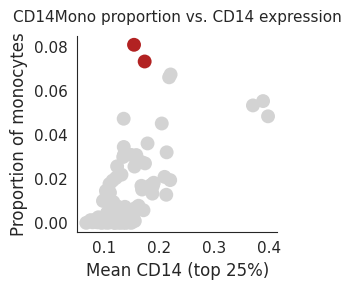

In [55]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(3, 3))
highlight = ["270", "271"]
colors = props_per_exp["Exp"].apply(
    lambda e: "firebrick" if e in highlight else "lightgray"
)
sns.scatterplot(
    data=props_per_exp,
    x="mean_cd14",
    y="prop_cd14mono_lin",
    s=100,
    edgecolor="none",
    color=colors,
    ax=ax,
)
ax.set_xlabel("Mean CD14 (top 25%)", fontsize=12)
ax.set_ylabel("Proportion of monocytes", fontsize=12)
ax.set_title("CD14Mono proportion vs. CD14 expression", fontsize=11, pad=10)
ax.tick_params(axis="both", labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("cd14mono_scatter.png", dpi=300, bbox_inches="tight")
plt.show()